# Évaluation — Expérimentations V2 (après Data Augmentation)
#### Waste Classification — MobileNetV2

Ce notebook évalue les **3 modèles entraînés dans `experiments_improvements_after_data_aug.ipynb`**
sur le dataset enrichi (trash augmenté offline).

| Modèle | Fichier | Technique |
|---|---|---|
| V2 Exp 1 | `v2_exp1_class_weights.keras` | Class Weights |
| V2 Exp 2 | `v2_exp2_fine_tuned.keras` | Fine-tuning (30 couches) |
| V2 Exp 3 | `v2_exp3_combined.keras` | Class Weights + Fine-tuning |

Tous les fichiers de sortie sont préfixés **`v2_eval_`** pour ne pas écraser
les résultats d'évaluation de la version originale.

---
## 1. Imports

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from tensorflow.keras.models import load_model

print('TensorFlow :', tf.__version__)

TensorFlow : 2.16.1


---
## 2. Chargement des 3 modèles V2

In [7]:
model_v2_exp1 = load_model('../model/v2_exp1_class_weights.keras')
model_v2_exp2 = load_model('../model/v2_exp2_fine_tuned.keras')
model_v2_exp3 = load_model('../model/v2_exp3_combined.keras')

print('✅ V2 Exp 1 chargé : v2_exp1_class_weights.keras')
print('✅ V2 Exp 2 chargé : v2_exp2_fine_tuned.keras')
print('✅ V2 Exp 3 chargé : v2_exp3_combined.keras')

✅ V2 Exp 1 chargé : v2_exp1_class_weights.keras
✅ V2 Exp 2 chargé : v2_exp2_fine_tuned.keras
✅ V2 Exp 3 chargé : v2_exp3_combined.keras


---
## 3. Reconstruction du test set

Même `seed=42` et même split 70/15/15 que pendant le training.

> Le dataset contient maintenant les images `trash` augmentées —
> le split est recalculé sur la nouvelle taille totale.

In [8]:
dataset_path = '../dataset'
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

full_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names   = full_dataset.class_names
total_batches = len(full_dataset)
train_size    = int(0.70 * total_batches)
val_size      = int(0.15 * total_batches)

test_dataset = (
    full_dataset
    .skip(train_size + val_size)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

print('Classes :', class_names)
print(f'Total batches  : {total_batches}')
print(f'Test batches   : {len(test_dataset)}')
print(f'~Images test   : {len(test_dataset) * BATCH_SIZE}')
print('✅ Test set reconstruit.')

Found 2936 files belonging to 6 classes.
Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total batches  : 92
Test batches   : 15
~Images test   : 480
✅ Test set reconstruit.


---
## 4. Vérification de l'équilibre du dataset augmenté

On vérifie que `trash` est bien rééquilibré avant d'évaluer.

In [9]:
print('Distribution des classes dans le dataset complet :')
print()
class_counts = np.zeros(len(class_names), dtype=np.int32)
for _, labels in full_dataset:
    for lbl in labels.numpy():
        class_counts[lbl] += 1

max_count = class_counts.max()
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    bar    = '█' * int(count / max_count * 30)
    status = '✅' if count >= max_count * 0.7 else '⚠️ '
    print(f'  {status} {name:12s} : {count:5d} images  {bar}')

print(f'\nTotal          : {class_counts.sum()} images')
print(f'Ratio min/max  : {class_counts.min()/class_counts.max():.2f}')
trash_idx = class_names.index('trash')
print(f'Classe trash   : {class_counts[trash_idx]} images')

Distribution des classes dans le dataset complet :

  ⚠️  cardboard    :   402 images  ████████████████████
  ✅ glass        :   501 images  █████████████████████████
  ⚠️  metal        :   409 images  ████████████████████
  ✅ paper        :   594 images  ██████████████████████████████
  ✅ plastic      :   482 images  ████████████████████████
  ✅ trash        :   548 images  ███████████████████████████

Total          : 2936 images
Ratio min/max  : 0.68
Classe trash   : 548 images


---
## 5. Fonction d'évaluation

In [10]:
def evaluate_model(model, test_dataset, class_names, exp_name, save_prefix):
    """Évalue un modèle V2 et sauvegarde les résultats avec save_prefix."""
    print(f'  ÉVALUATION — {exp_name}')

    loss, acc = model.evaluate(test_dataset, verbose=0)
    print(f'  Test Accuracy : {acc*100:.2f}%')
    print(f'  Test Loss     : {loss:.4f}')
    print(f'  vs Baseline   : 84.50%  ({acc*100 - 84.50:+.2f}%)')
    print()

    preds        = model.predict(test_dataset, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.concatenate([y.numpy() for _, y in test_dataset])

    print(classification_report(true_classes, pred_classes,
                                target_names=class_names, digits=3))

    # Recall trash
    recall_pc   = recall_score(true_classes, pred_classes, average=None)
    t_idx       = class_names.index('trash')
    trash_recall = recall_pc[t_idx]
    print(f'  Trash recall  : {trash_recall*100:.1f}%  (baseline : 70.4%  |  delta : {(trash_recall-0.704)*100:+.1f} pts)')
    print()

    # Matrice de confusion + accuracy par classe
    cm = confusion_matrix(true_classes, pred_classes)
    per_class = cm.diagonal() / cm.sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white', ax=axes[0])
    for i in range(len(class_names)):
        axes[0].add_patch(plt.Rectangle((i,i),1,1,fill=True,
                          color='#2ecc71',alpha=0.35,lw=0))
    axes[0].set_title(f'Matrice de confusion — {exp_name}', fontsize=11)
    axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
    plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

    colors = ['#2ecc71' if a>=0.80 else '#f39c12' if a>=0.60 else '#e74c3c'
              for a in per_class]
    bars = axes[1].bar(class_names, per_class*100, color=colors,
                       edgecolor='white', linewidth=0.8)
    for bar, a in zip(bars, per_class):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
                     f'{a*100:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[1].axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[1].set_ylim(0, 108)
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy par classe', fontsize=11)
    patches = [
        mpatches.Patch(color='#2ecc71', label='>= 80%'),
        mpatches.Patch(color='#f39c12', label='60-80%'),
        mpatches.Patch(color='#e74c3c', label='< 60%'),
    ]
    axes[1].legend(handles=patches, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'../model/{save_prefix}_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    np.save(f'../model/{save_prefix}_true.npy',      true_classes)
    np.save(f'../model/{save_prefix}_predicted.npy', pred_classes)

    return acc, loss, per_class, trash_recall, true_classes, pred_classes

print('Fonction evaluate_model prête.')

Fonction evaluate_model prête.


---
## 6. Évaluation — V2 Exp 1 (Class Weights)

  ÉVALUATION — V2 Exp 1 — Class Weights
  Test Accuracy : 87.92%
  Test Loss     : 0.3816
  vs Baseline   : 84.50%  (+3.42%)

              precision    recall  f1-score   support

   cardboard      0.909     0.943     0.926        53
       glass      0.859     0.798     0.827        84
       metal      0.857     0.892     0.874        74
       paper      0.931     0.905     0.918       105
     plastic      0.722     0.891     0.797        64
       trash      0.988     0.870     0.925        92

    accuracy                          0.879       472
   macro avg      0.878     0.883     0.878       472
weighted avg      0.887     0.879     0.881       472

  Trash recall  : 87.0%  (baseline : 70.4%  |  delta : +16.6 pts)



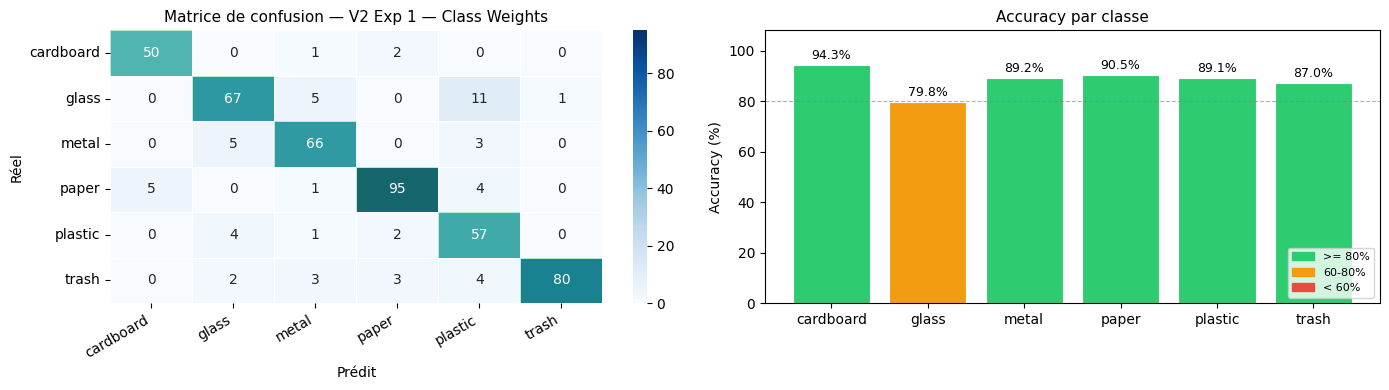

In [11]:
acc_v2e1, loss_v2e1, pca_v2e1, tr_v2e1, true_v2e1, pred_v2e1 = evaluate_model(
    model_v2_exp1, test_dataset, class_names,
    exp_name='V2 Exp 1 — Class Weights',
    save_prefix='v2_eval_exp1'
)

---
## 7. Évaluation — V2 Exp 2 (Fine-tuning)

  ÉVALUATION — V2 Exp 2 — Fine-tuning
  Test Accuracy : 87.71%
  Test Loss     : 0.3744
  vs Baseline   : 84.50%  (+3.21%)

              precision    recall  f1-score   support

   cardboard      0.860     0.925     0.891        53
       glass      0.811     0.869     0.839        84
       metal      0.833     0.878     0.855        74
       paper      0.930     0.886     0.907       105
     plastic      0.864     0.797     0.829        64
       trash      0.943     0.902     0.922        92

    accuracy                          0.877       472
   macro avg      0.874     0.876     0.874       472
weighted avg      0.879     0.877     0.877       472

  Trash recall  : 90.2%  (baseline : 70.4%  |  delta : +19.8 pts)



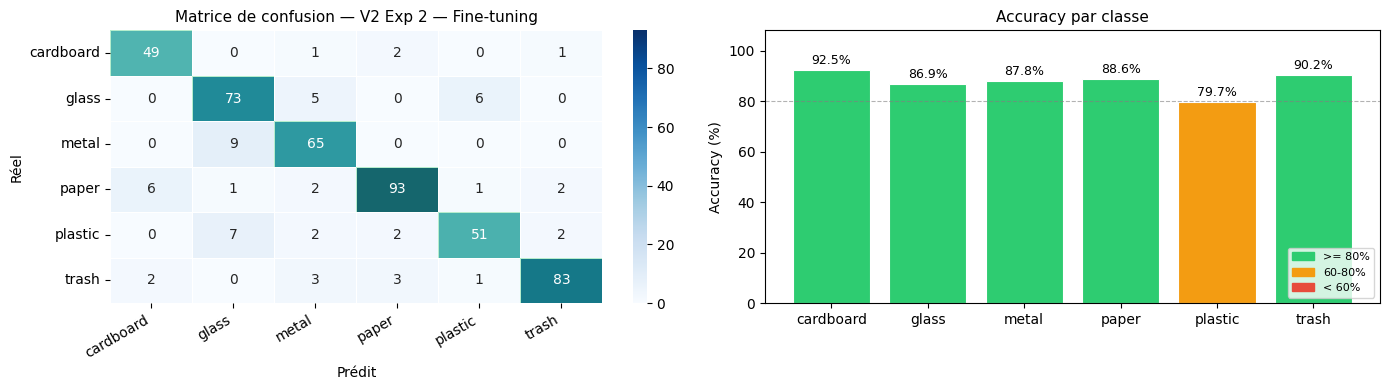

In [12]:
acc_v2e2, loss_v2e2, pca_v2e2, tr_v2e2, true_v2e2, pred_v2e2 = evaluate_model(
    model_v2_exp2, test_dataset, class_names,
    exp_name='V2 Exp 2 — Fine-tuning',
    save_prefix='v2_eval_exp2'
)

---
## 8. Évaluation — V2 Exp 3 (Class Weights + Fine-tuning)

  ÉVALUATION — V2 Exp 3 — CW + Fine-tuning
  Test Accuracy : 89.62%
  Test Loss     : 0.3515
  vs Baseline   : 84.50%  (+5.12%)

              precision    recall  f1-score   support

   cardboard      0.907     0.925     0.916        53
       glass      0.841     0.881     0.860        84
       metal      0.863     0.932     0.896        74
       paper      0.924     0.924     0.924       105
     plastic      0.828     0.828     0.828        64
       trash      1.000     0.880     0.936        92

    accuracy                          0.896       472
   macro avg      0.894     0.895     0.893       472
weighted avg      0.899     0.896     0.897       472

  Trash recall  : 88.0%  (baseline : 70.4%  |  delta : +17.6 pts)



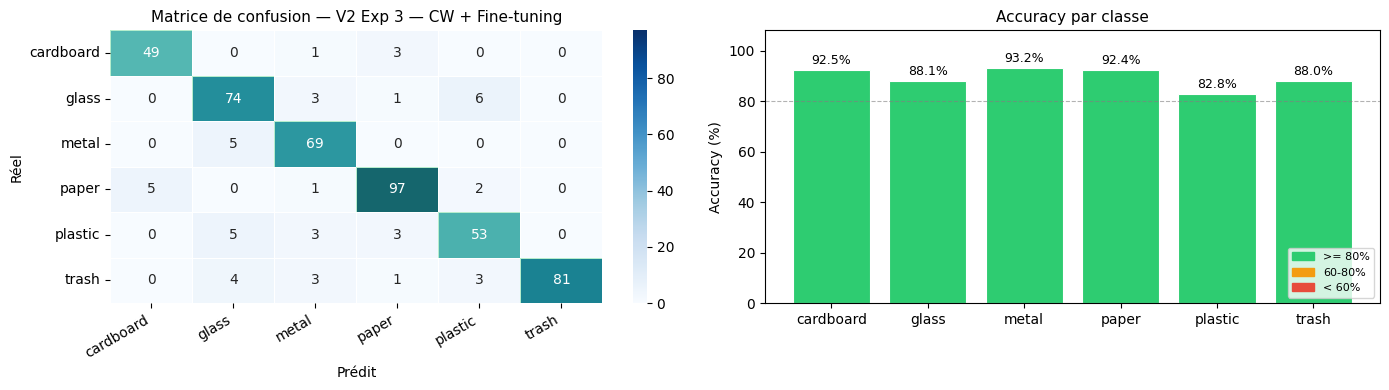

In [13]:
acc_v2e3, loss_v2e3, pca_v2e3, tr_v2e3, true_v2e3, pred_v2e3 = evaluate_model(
    model_v2_exp3, test_dataset, class_names,
    exp_name='V2 Exp 3 — CW + Fine-tuning',
    save_prefix='v2_eval_exp3'
)

---
## 9. Comparaison V2 Exp 1 / 2 / 3 — Accuracy par classe

Vue synthétique pour choisir le meilleur modèle V2.

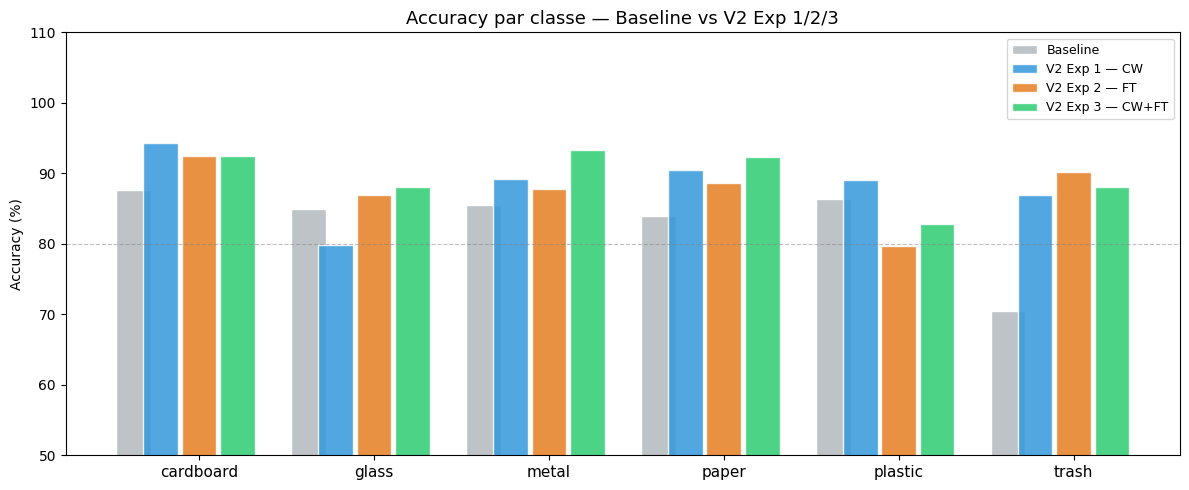

In [14]:
baseline_per_class = {
    'cardboard': 0.877, 'glass': 0.849, 'metal': 0.855,
    'paper': 0.840, 'plastic': 0.864, 'trash': 0.704
}

models_pca = {
    'V2 Exp 1 — CW'     : pca_v2e1,
    'V2 Exp 2 — FT'     : pca_v2e2,
    'V2 Exp 3 — CW+FT'  : pca_v2e3,
}

x     = np.arange(len(class_names))
width = 0.22
offsets = [-width, 0, width]
colors  = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 5))

baseline_vals = [baseline_per_class[c] * 100 for c in class_names]
ax.bar(x - width*1.7, baseline_vals, width*0.9,
       label='Baseline', color='#bdc3c7', edgecolor='white')

for (name, pca), offset, color in zip(models_pca.items(), offsets, colors):
    ax.bar(x + offset, pca * 100, width*0.9,
           label=name, color=color, edgecolor='white', alpha=0.85)

ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(50, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy par classe — Baseline vs V2 Exp 1/2/3', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../model/v2_eval_per_class_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Comparaison globale — Baseline / V1 / V2

In [15]:
results_all = {
    'Baseline'           : 0.8450,
    'V1 Exp 1 — CW'      : 0.8596,
    'V1 Exp 2 — FT'      : 0.8741,
    'V1 Exp 3 — CW+FT'   : 0.8717,
    'V2 Exp 1 — CW'      : acc_v2e1,
    'V2 Exp 2 — FT'      : acc_v2e2,
    'V2 Exp 3 — CW+FT'   : acc_v2e3,
}

trash_recalls = {
    'Baseline'           : 0.704,
    'V1 Exp 1 — CW'      : None,
    'V1 Exp 2 — FT'      : None,
    'V1 Exp 3 — CW+FT'   : None,
    'V2 Exp 1 — CW'      : tr_v2e1,
    'V2 Exp 2 — FT'      : tr_v2e2,
    'V2 Exp 3 — CW+FT'   : tr_v2e3,
}

print('=' * 68)
print('  COMPARAISON GLOBALE — TOUTES VERSIONS')
print('=' * 68)
print(f'  {"Modèle":24s}  {"Accuracy":>10s}  {"vs Baseline":>12s}  {"Trash recall":>14s}')
print('─' * 68)
for name, acc in results_all.items():
    delta = acc - 0.8450
    sign  = '+' if delta >= 0 else ''
    tr    = trash_recalls[name]
    tr_str = f'{tr*100:.1f}%' if tr is not None else '—'
    best  = ' ← MEILLEUR' if acc == max(results_all.values()) else ''
    print(f'  {name:24s}  {acc*100:>9.2f}%  {sign}{delta*100:>10.2f}%  {tr_str:>14s}{best}')
print('=' * 68)

  COMPARAISON GLOBALE — TOUTES VERSIONS
  Modèle                      Accuracy   vs Baseline    Trash recall
────────────────────────────────────────────────────────────────────
  Baseline                      84.50%  +      0.00%           70.4%
  V1 Exp 1 — CW                 85.96%  +      1.46%               —
  V1 Exp 2 — FT                 87.41%  +      2.91%               —
  V1 Exp 3 — CW+FT              87.17%  +      2.67%               —
  V2 Exp 1 — CW                 87.92%  +      3.42%           87.0%
  V2 Exp 2 — FT                 87.71%  +      3.21%           90.2%
  V2 Exp 3 — CW+FT              89.62%  +      5.12%           88.0% ← MEILLEUR


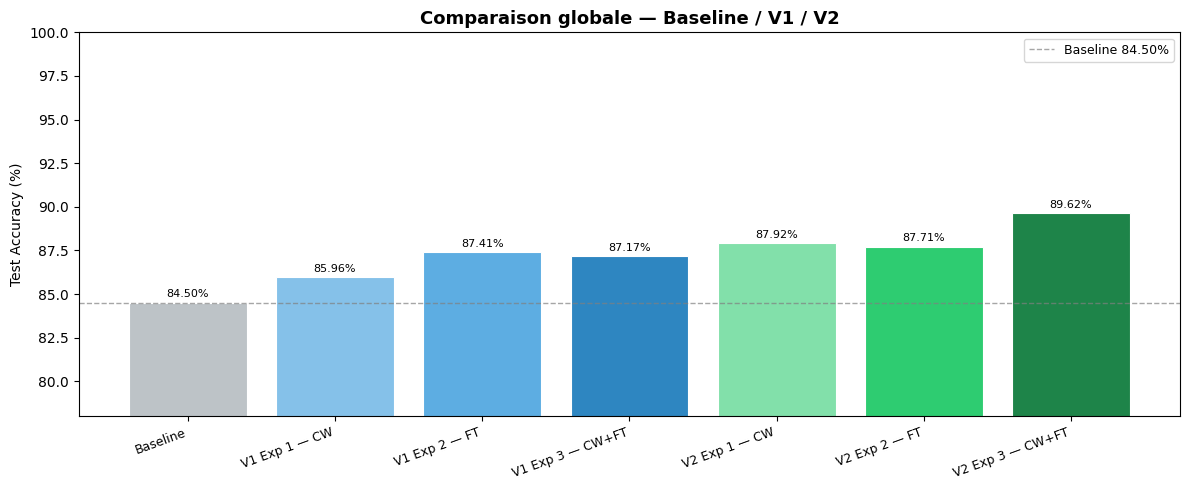

In [16]:
# ── Graphique comparaison globale ────────────────────────────────────
names  = list(results_all.keys())
values = [v * 100 for v in results_all.values()]
colors_bar = [
    '#bdc3c7',                    # Baseline
    '#85c1e9', '#5dade2', '#2e86c1',  # V1
    '#82e0aa', '#2ecc71', '#1e8449',  # V2
]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, values, color=colors_bar, edgecolor='white', linewidth=0.8)
ax.axhline(84.50, color='gray', linestyle='--', linewidth=1,
           alpha=0.7, label='Baseline 84.50%')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=8)
ax.set_ylim(78, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Comparaison globale — Baseline / V1 / V2', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('../model/v2_eval_global_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Récapitulatif final

In [17]:
best_v2_name = max({'V2 Exp 1 — CW': acc_v2e1, 'V2 Exp 2 — FT': acc_v2e2,
                     'V2 Exp 3 — CW+FT': acc_v2e3}, key=lambda k: {'V2 Exp 1 — CW': acc_v2e1,
                     'V2 Exp 2 — FT': acc_v2e2, 'V2 Exp 3 — CW+FT': acc_v2e3}[k])

print('=' * 62)
print('  RÉCAPITULATIF — ÉVALUATION V2 (Dataset Augmenté)')
print('=' * 62)
print(f'  Dataset        : enrichi (trash x3 offline)')
print(f'  Images testées : ~{len(test_dataset) * BATCH_SIZE}')
print()
print(f'  {"Modèle":22s}  {"Accuracy":>10s}  {"Trash recall":>14s}')
print('  ' + '─'*50)
rows = [
    ('Baseline',          0.8450,   0.704),
    ('V2 Exp 1 — CW',     acc_v2e1, tr_v2e1),
    ('V2 Exp 2 — FT',     acc_v2e2, tr_v2e2),
    ('V2 Exp 3 — CW+FT',  acc_v2e3, tr_v2e3),
]
for name, acc, tr in rows:
    best_mark = ' ←' if name != 'Baseline' and acc == max(acc_v2e1, acc_v2e2, acc_v2e3) else ''
    print(f'  {name:22s}  {acc*100:>9.2f}%  {tr*100:>13.1f}%{best_mark}')
print('=' * 62)
print()
print('  Fichiers sauvegardés :')
print('    v2_eval_exp1_results.png')
print('    v2_eval_exp2_results.png')
print('    v2_eval_exp3_results.png')
print('    v2_eval_per_class_comparison.png')
print('    v2_eval_global_comparison.png')
print('    v2_eval_exp{1,2,3}_true.npy / predicted.npy')

  RÉCAPITULATIF — ÉVALUATION V2 (Dataset Augmenté)
  Dataset        : enrichi (trash x3 offline)
  Images testées : ~480

  Modèle                    Accuracy    Trash recall
  ──────────────────────────────────────────────────
  Baseline                    84.50%           70.4%
  V2 Exp 1 — CW               87.92%           87.0%
  V2 Exp 2 — FT               87.71%           90.2%
  V2 Exp 3 — CW+FT            89.62%           88.0% ←

  Fichiers sauvegardés :
    v2_eval_exp1_results.png
    v2_eval_exp2_results.png
    v2_eval_exp3_results.png
    v2_eval_per_class_comparison.png
    v2_eval_global_comparison.png
    v2_eval_exp{1,2,3}_true.npy / predicted.npy
